In [1]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import ListedColormap

Text(0, 0.5, '% gene on phage')

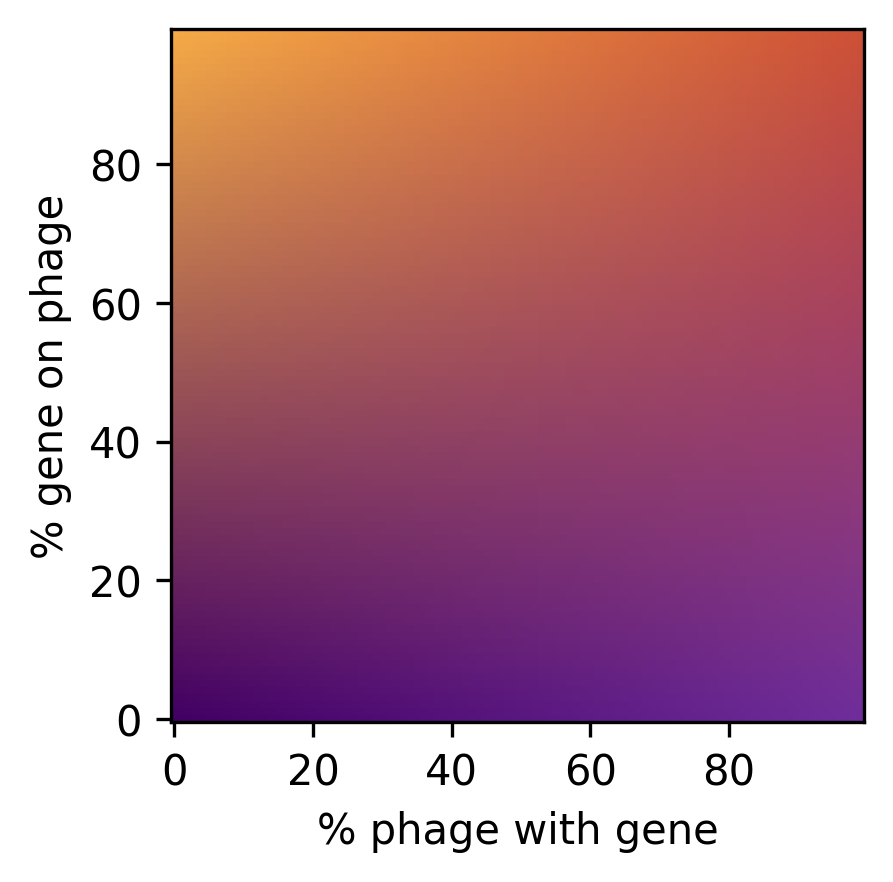

In [5]:
# Define colormap for parameter sweeps

def hex_to_rgb_array(hex_code):
    """
    Convert a hex color code to a 3D NumPy array of RGB values.
    
    Args:
        hex_code (str): A hex color string (e.g., "#FF5733").
        
    Returns:
        np.ndarray: A (1,1,3) array representing the RGB values.
    """
    # Remove the '#' if present
    hex_code = hex_code.lstrip('#')
    
    # Convert hex to RGB tuple
    rgb = tuple(int(hex_code[i:i+2], 16) for i in (0, 2, 4))
    
    # Convert to NumPy array with shape (1,1,3)
    rgb_array = np.array(rgb, dtype=np.uint8).reshape(1, 1, 3)
    
    return rgb_array

# Below are colours generated for the corners of the colour map from hex codes
c00 = np.array([0.25882353, 0.        , 0.39215686])
c01 = np.array([0.43529412, 0.18039216, 0.61176471])
c10 = np.array([0.96862745, 0.6745098 , 0.2745098])
c11 = np.array([0.80784314, 0.31372549, 0.20784314])

# Define colour map as a linear combination of the corner colours
cm = np.zeros((100, 100,3))
j=0
for pi in np.logspace(-5,0,100):
    i=0
    for alpha in np.linspace(-5,-1,100):
        cm[i][j] = (1 - i/100) * (1 - j/100) * c00 + (1 - i/100) * j/100 * c01 + i/100 * (1 - j/100) * c10 + i/100 * j/100 * c11
        i+=1
    j+=1

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 3), dpi=300)
ax.imshow(cm, origin="lower")
ax.set_xlabel("% phage with gene")
ax.set_ylabel("% gene on phage")

In [3]:
hex_to_rgb_array('fffb9e')

array([[[255, 251, 158]]], dtype=uint8)

In [3]:
def get_RGBA(result):
    phage = result[:, :, -2].T
    gene = result[:, :, -1].T
    
    # Define corner colors in RGBA
    c00 = np.array([0.25882353, 0.        , 0.39215686])
    c01 = np.array([0.43529412, 0.18039216, 0.61176471])
    c10 = np.array([0.96862745, 0.6745098 , 0.2745098])
    c11 = np.array([0.80784314, 0.31372549, 0.20784314])
    
    pers = np.zeros((100, 100, 3))  # RGBA array
    
    j = 0
    for pi in np.logspace(-5, 0, 100):
        i = 0
        for alpha in np.linspace(-5, -1, 100):
            if np.isnan(gene[i, j]) or np.isnan(phage[i, j]):
                pers[i, j] = [1, 1, 1]  # White, fully opaque
            else:
                # Perform bilinear interpolation
                g, p = gene[i, j], phage[i, j]
                pers[i, j] = (1 - g) * (1 - p) * c00 + (1 - g) * p * c01 + g * (1 - p) * c10 + g * p * c11
            i += 1
        j += 1
    
    return pers

In [4]:
# Define model

def model2comp(y, t, pi, alpha, alphae, mu, loss, phi, beta, rV, delta, d, im, K):
    
    # Define state variables. Addition of 'e' denotes variable is in the outside world
    U, Uc, L, Lc, Lp, Lcp, V, VT, Ue, Uce, Le, Lce, Lpe, Lcpe, Ve, VTe = y

    N = U + Uc + L + Lc + Lp + Lcp
    NT = Uc + Lc + Lp + Lcp
    Ne = Ue + Uce + Le + Lce + Lpe + Lcpe
    
    ####... growth/death....... selection................... infection............ lysis.... mutations/decay................. migration.....

    dydt = [U*(1 - d - N      + (1-pi)*phi*NT/N)           - beta*U*(V + VT)               + loss*(L + Lp) + mu*Uc          + im*(Ue-U)    ,
            Uc*(1 - d - N     + pi*phi + (1-pi)*phi*NT/N)  - beta*Uc*(V + VT)              + loss*(Lc + Lcp) - mu*Uc        + im*(Uce-Uc)  ,
            L*(1 - d - N      + (1-pi)*phi*NT/N)           + beta*U*V            - (alpha  + loss)*L + mu*Lc + mu*Lp        + im*(Le-L)    ,
            Lc*(1 - d - N     + pi*phi + (1-pi)*phi*NT/N)  + beta*Uc*V           - (alpha  + loss)*Lc - mu*Lc + mu*Lcp      + im*(Lce-Lc)  ,
            Lp*(1 - d - N     + pi*phi + (1-pi)*phi*NT/N)  + beta*U*VT           - (alpha  + loss)*Lp - mu*Lp + mu*Lcp      + im*(Lpe-Lp)  ,
            Lcp*(1 - d - N    + pi*phi + (1-pi)*phi*NT/N)  + beta*Uc*VT          - (alpha  + loss)*Lcp - mu*Lcp - mu*Lcp    + im*(Lcpe-Lcp),
            rV*alpha*(L + Lc)                              - beta*(U+Uc)*V                 - delta*V                        + im*(Ve-V)    ,
            rV*alpha*(Lp + Lcp)                            - beta*(U+Uc)*VT                - delta*VT                       + im*(VTe-VT)  ,
            Ue*(K - d - Ne)                                - beta*Ue*(Ve + VTe)            + loss*(Le + Lpe) + mu*Uce       + im*(U-Ue)    ,
            Uce*(K - d - Ne)                               - beta*Uce*(Ve + VTe)           + loss*(Lce + Lcpe) - mu*Uce     + im*(Uc-Uce)  ,
            Le*(K - d - Ne)                                + beta*Ue*Ve          - (alphae + loss)*Le + mu*Lce + mu*Lpe     + im*(L-Le)    ,
            Lce*(K - d - Ne)                               + beta*Uce*Ve         - (alphae + loss)*Lce - mu*Lce + mu*Lcpe   + im*(Lc-Lce)  ,
            Lpe*(K - d - Ne)                               + beta*Ue*VTe         - (alphae + loss)*Lpe - mu*Lpe + mu*Lcpe   + im*(Lp-Lpe)  ,
            Lcpe*(K - d - Ne)                              + beta*Uce*VTe        - (alphae + loss)*Lcpe - mu*Lcpe - mu*Lcpe + im*(Lcp-Lcpe),
            rV*alphae*(Le + Lce)                           - beta*(Ue+Uce)*Ve              - delta*Ve                       + im*(V-Ve)    ,
            rV*alphae*(Lpe + Lcpe)                         - beta*(Ue+Uce)*VTe             - delta*VTe                      + im*(VT-VTe)   ]

    return dydt

In [5]:
# Run simulation for closed host compartment (unstructured environment)

result_1comp = []

# Assign parameter values

beta = 0.04         # phage infection rate
loss = 0.002        # Rate of prophage loss
mu = 0.0002          # Rate of gene loss
rV = 30             # phage burst size
delta = 0.04        # Rate of virion decay
d = 0.02            # Cell intrinsic death rate
im = 0.0            # Migration rate between the two compartments
K = 2               # Carrying capacity in the outside world compartment               
alphae = 0.001      # Rate of prophage induction in the outside world compartment
phi = 1             # Maximum increase in carrying capacity due to benefits from gene in the host compartment

# For different values of pi (privatization of benefits within the host compertment) on the log-scale
for pi in np.logspace(-4.5,-1,100):
    alphavals = []
    # For different values of alpha (rate of prophage induction within the host compartment) on the log-scale
    for alpha in np.logspace(-4.5,-1,100):
        
        # Initial condition: Host contains 99% Lc and 1% Lp at carrying capacity, Outside world contains U at carrying capacity
        y0 = [0.00, 0.00, 0.00, 1.98, 0.02, 0.00, 0.00, 0.00, 2.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00]
        ##    U     Uc    L     Lc    Lp    Lcp   V     VT    Ue    Uce   Le    Lce   Lpe   Lcpe  Ve    VTe

        t = np.linspace(0, 1000000, 100001)
        sol = odeint(model2comp, y0, t, args=(pi, alpha, alphae, mu, loss, phi, beta, rV, delta, d, im, K))
        
        data = pd.DataFrame(sol, columns = ["U", "Uc", "L", "Lc", "Lp", "Lcp", "V", "VT","Ue", "Uce", "Le", "Lce", "Lpe", "Lcpe", "Ve", "VTe"])
        data[data<10**-6]=0
        data['phageG'] = (data['Lp']+data['Lcp'])/(data['L']+data['Lc']+data['Lp']+data['Lcp'])
        data['geneP'] = (data['Lp']+data['Lcp'])/(data['Uc']+data['Lc']+data['Lp']+2*data['Lcp'])
        
        alphavals.append(data.iloc[-1])
    result_1comp.append(alphavals)

In [6]:
# Run simulation for open host compartment (with migration between host and outside world)

result_2comp = []

# Assign parameter values

beta = 0.04         # phage infection rate
loss = 0.002        # Rate of prophage loss
mu = 0.0002          # Rate of gene loss
rV = 30             # phage burst size
delta = 0.04        # Rate of virion decay
d = 0.02            # Cell intrinsic death rate
im = 0.001            # Migration rate between the two compartments
K = 2               # Carrying capacity in the outside world compartment               
phi = 1             # Maximum increase in carrying capacity due to benefits from gene in the host compartment

# For different values of alphae (rate of prophage induction in the outside world compartment)
for alphae in [0, 0.0001, 0.001, 0.01]:
    result = []
    # For different values of pi (privatization of benefits within the host compertment) on the log-scale
    for pi in np.logspace(-4.5,-1,100):
        alphavals = []
        # For different values of alpha (rate of prophage induction within the host compartment) on the log-scale
        for alpha in np.logspace(-4.5,-1,100):
           
            # Initial condition: Host contains 99% Lc and 1% Lp at carrying capacity, Outside world contains U at carrying capacity
            y0 = [0.00, 0.00, 0.00, 1.98, 0.02, 0.00, 0.00, 0.00, 2.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00]
            ##    U     Uc    L     Lc    Lp    Lcp   V     VT    Ue    Uce   Le    Lce   Lpe   Lcpe  Ve    VTe

            t = np.linspace(0, 1000000, 100001)
            sol = odeint(model2comp, y0, t, args=(pi, alpha, alphae, mu, loss, phi, beta, rV, delta, d, im, K))
            
            data = pd.DataFrame(sol, columns = ["U", "Uc", "L", "Lc", "Lp", "Lcp", "V", "VT","Ue", "Uce", "Le", "Lce", "Lpe", "Lcpe", "Ve", "VTe"])
            data[data<10**-6]=0
            data['phageG'] = (data['Lp']+data['Lcp'])/(data['L']+data['Lc']+data['Lp']+data['Lcp'])
            data['geneP'] = (data['Lp']+data['Lcp'])/(data['Uc']+data['Lc']+data['Lp']+2*data['Lcp'])
            
            alphavals.append(data.iloc[-1])
        result.append(alphavals)
    result_2comp.append(result)

In [7]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 16), dpi=600)

dat = get_RGBA(np.array(result_1comp))
ax[0][0].imshow(dat, origin="lower")
ax[0][0].set_xticks(np.linspace(0,99,8), np.linspace(-4.5,-1,8))
ax[0][0].set_yticks(np.linspace(0,99,8), np.linspace(-4.5,-1,8))
        
gene = np.array(result_1comp)[:,:,-1].T
gene = np.nan_to_num(gene, nan=-1)
gene[gene>=0] = np.nan
gene_mask = np.ma.masked_less(gene, 1)

phage = np.array(result_1comp)[:,:,-2].T
phage = np.nan_to_num(phage, nan=-1)
phage[phage>=0] = np.nan
phage_mask = np.ma.masked_less(phage, 1)
        
ax[0][0].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data, hatch='///', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Gene extinct")
ax[0][0].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), phage_mask.data, hatch='\\\\\\', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Phage extinct")
ax[0][0].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data+phage_mask.data, hatch='xxx', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="")
ax[0][0].set_xlabel(r"Privatization (log-scaled), $\log_{10}\pi$",  fontsize=13)
ax[0][0].set_ylabel(r"Induction rate (log-scaled), $\log_{10}\alpha$", fontsize=13)

ax[0][1].set_title("Color map", fontsize=15)
ax[0][1].imshow(cm, origin="lower")
ax[0][1].set_xticks([0,25,50,75])
ax[0][1].set_yticks([0,25,50,75])
ax[0][1].set_xlabel("% phage with gene",  fontsize=13)
ax[0][1].set_ylabel("% gene on phage",  fontsize=13)

axes = [ax[1][0], ax[1][1], ax[2][0], ax[2][1]]


for jj in range(4):
    dat = get_RGBA(np.array(result_2comp[jj]))
    axes[jj].imshow(dat, origin="lower")
    axes[jj].set_xticks(np.linspace(0,100,8), np.linspace(-4.5,-1,8))
    axes[jj].set_yticks(np.linspace(0,100,8), np.linspace(-4.5,-1,8))
        
    gene = np.array(result_2comp[jj])[:,:,-1].T
    gene = np.nan_to_num(gene, nan=-1)
    gene[gene>=0] = np.nan
    gene_mask = np.ma.masked_less(gene, 1)

    phage = np.array(result_2comp[jj])[:,:,-2].T
    phage = np.nan_to_num(phage, nan=-1)
    phage[phage>=0] = np.nan
    phage_mask = np.ma.masked_less(phage, 1)
        
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data, hatch='///', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Gene extinct")
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), phage_mask.data, hatch='\\\\\\', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Phage extinct")
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data+phage_mask.data, hatch='xxx', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="")

fig.text(0.5, 0.0, r"Privatization (log-scaled), $\log_{10}\pi$", ha='center',  fontsize=13)
fig.text(0.0, 0.33, r"Induction rate in the host compartment (log-scaled), $\log_{10}\alpha$", va='center', rotation='vertical',  fontsize=13)

ax[1][0].set_title(r"$\alpha_{out}=0$",  fontsize=15)
ax[1][1].set_title(r"$\alpha_{out}=10^{-4}$",  fontsize=15)
ax[2][0].set_title(r"$\alpha_{out}=10^{-3}$",  fontsize=15)
ax[2][1].set_title(r"$\alpha_{out}=10^{-2}$",  fontsize=15)

plt.tight_layout()
#plt.savefig("fig_2compt_all.png")

In [19]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 16), dpi=600)

dat = get_RGBA(np.array(result_1comp_IwGR))
ax[0][0].imshow(dat, origin="lower")
ax[0][0].set_xticks(np.linspace(0,99,8), np.linspace(-4.5,-1,8))
ax[0][0].set_yticks(np.linspace(0,99,8), np.linspace(-4.5,-1,8))
        
gene = np.array(result_1comp_IwGR)[:,:,-1].T
gene = np.nan_to_num(gene, nan=-1)
gene[gene>=0] = np.nan
gene_mask = np.ma.masked_less(gene, 1)

phage = np.array(result_1comp_IwGR)[:,:,-2].T
phage = np.nan_to_num(phage, nan=-1)
phage[phage>=0] = np.nan
phage_mask = np.ma.masked_less(phage, 1)
        
ax[0][0].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data, hatch='///', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Gene extinct")
ax[0][0].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), phage_mask.data, hatch='\\\\\\', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Phage extinct")
ax[0][0].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data+phage_mask.data, hatch='xxx', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="")
ax[0][0].set_xlabel(r"Privatization (log-scaled), $\log_{10}\pi$",  fontsize=13)
ax[0][0].set_ylabel(r"Induction rate (log-scaled), $\log_{10}\alpha$", fontsize=13)

ax[0][1].set_title("Color map", fontsize=15)
ax[0][1].imshow(cm, origin="lower")
ax[0][1].set_xticks([0,25,50,75])
ax[0][1].set_yticks([0,25,50,75])
ax[0][1].set_xlabel("% phage with gene",  fontsize=13)
ax[0][1].set_ylabel("% gene on phage",  fontsize=13)

axes = [ax[1][0], ax[1][1], ax[2][0], ax[2][1]]


for jj in range(4):
    dat = get_RGBA(np.array(result_2comp_IwGR[jj]))
    axes[jj].imshow(dat, origin="lower")
    axes[jj].set_xticks(np.linspace(0,100,8), np.linspace(-4.5,-1,8))
    axes[jj].set_yticks(np.linspace(0,100,8), np.linspace(-4.5,-1,8))
        
    gene = np.array(result_2comp_IwGR[jj])[:,:,-1].T
    gene = np.nan_to_num(gene, nan=-1)
    gene[gene>=0] = np.nan
    gene_mask = np.ma.masked_less(gene, 1)

    phage = np.array(result_2comp_IwGR[jj])[:,:,-2].T
    phage = np.nan_to_num(phage, nan=-1)
    phage[phage>=0] = np.nan
    phage_mask = np.ma.masked_less(phage, 1)
        
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data, hatch='///', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Gene extinct")
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), phage_mask.data, hatch='\\\\\\', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Phage extinct")
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data+phage_mask.data, hatch='xxx', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="")

fig.text(0.5, 0.0, r"Privatization (log-scaled), $\log_{10}\pi$", ha='center',  fontsize=13)
fig.text(0.0, 0.33, r"Induction rate in the host compartment (log-scaled), $\log_{10}\alpha$", va='center', rotation='vertical',  fontsize=13)

ax[1][0].set_title(r"$\alpha_{out}=0$",  fontsize=15)
ax[1][1].set_title(r"$\alpha_{out}=10^{-4}$",  fontsize=15)
ax[2][0].set_title(r"$\alpha_{out}=10^{-3}$",  fontsize=15)
ax[2][1].set_title(r"$\alpha_{out}=10^{-2}$",  fontsize=15)

plt.tight_layout()
plt.savefig("fig_2compt_IwGR.png")

In [9]:
# Define model

def model1comp(y, t, pi, alpha, mu, loss, phi, beta, rV, delta, d):
    
    # Define state variables.
    U, Uc, L, Lc, Lp, Lcp, V, VT = y

    N = U + Uc + L + Lc + Lp + Lcp
    NT = Uc + Lc + Lp + Lcp
    
    ####... growth/death....... selection................... infection............ lysis.... mutations/decay................. migration.....

    dydt = [U*(1 - d - N      + (1-pi)*phi*NT/N)           - beta*U*(V + VT)               + loss*(L + Lp) + mu*Uc          ,
            Uc*(1 - d - N     + pi*phi + (1-pi)*phi*NT/N)  - beta*Uc*(V + VT)              + loss*(Lc + Lcp) - mu*Uc        ,
            L*(1 - d - N      + (1-pi)*phi*NT/N)           + beta*U*V            - (alpha  + loss)*L + mu*Lc + mu*Lp        ,
            Lc*(1 - d - N     + pi*phi + (1-pi)*phi*NT/N)  + beta*Uc*V           - (alpha  + loss)*Lc - mu*Lc + mu*Lcp      ,
            Lp*(1 - d - N     + pi*phi + (1-pi)*phi*NT/N)  + beta*U*VT           - (alpha  + loss)*Lp - mu*Lp + mu*Lcp      ,
            Lcp*(1 - d - N    + pi*phi + (1-pi)*phi*NT/N)  + beta*Uc*VT          - (alpha  + loss)*Lcp - mu*Lcp - mu*Lcp    ,
            rV*alpha*(L + Lc)                              - beta*(U+Uc)*V                 - delta*V                        ,
            rV*alpha*(Lp + Lcp)                            - beta*(U+Uc)*VT                - delta*VT]                   

    return dydt

In [48]:
# Run simulation for closed host compartment (unstructured environment) - sensitivity analysis

result_1comp_beta = []

# Assign parameter values

beta = 0.04         # phage infection rate
loss = 0.002        # Rate of prophage loss
mu = 0.0002          # Rate of gene loss
rV = 30             # phage burst size
delta = 0.04        # Rate of virion decay
d = 0.02            # Cell intrinsic death rate
phi = 1             # Maximum increase in carrying capacity due to benefits from gene

for beta in [0.004, 0.04, 0.4]:
    sweep = []
    # For different values of pi (privatization of benefits within the host compertment) on the log-scale
    for pi in np.logspace(-4.5,-1,100):
        alphavals = []
        # For different values of alpha (rate of prophage induction within the host compartment) on the log-scale
        for alpha in np.logspace(-4.5,-1,100):
        
            # Initial condition: Host contains 99% Lc and 1% Lp at carrying capacity, Outside world contains U at carrying capacity
            y0 = [0.00, 0.00, 0.00, 1.98, 0.02, 0.00, 0.00, 0.00]
            ##    U     Uc    L     Lc    Lp    Lcp   V     VT   

            t = np.linspace(0, 1000000, 100001)
            sol = odeint(model1comp, y0, t, args=(pi, alpha, mu, loss, phi, beta, rV, delta, d))
        
            data = pd.DataFrame(sol, columns = ["U", "Uc", "L", "Lc", "Lp", "Lcp", "V", "VT"])
            data[data<10**-6]=0
            data['phageG'] = (data['Lp']+data['Lcp'])/(data['L']+data['Lc']+data['Lp']+data['Lcp'])
            data['geneP'] = (data['Lp']+data['Lcp'])/(data['Uc']+data['Lc']+data['Lp']+2*data['Lcp'])
        
            alphavals.append(data.iloc[-1])
        sweep.append(alphavals)
    result_1comp_beta.append(sweep)

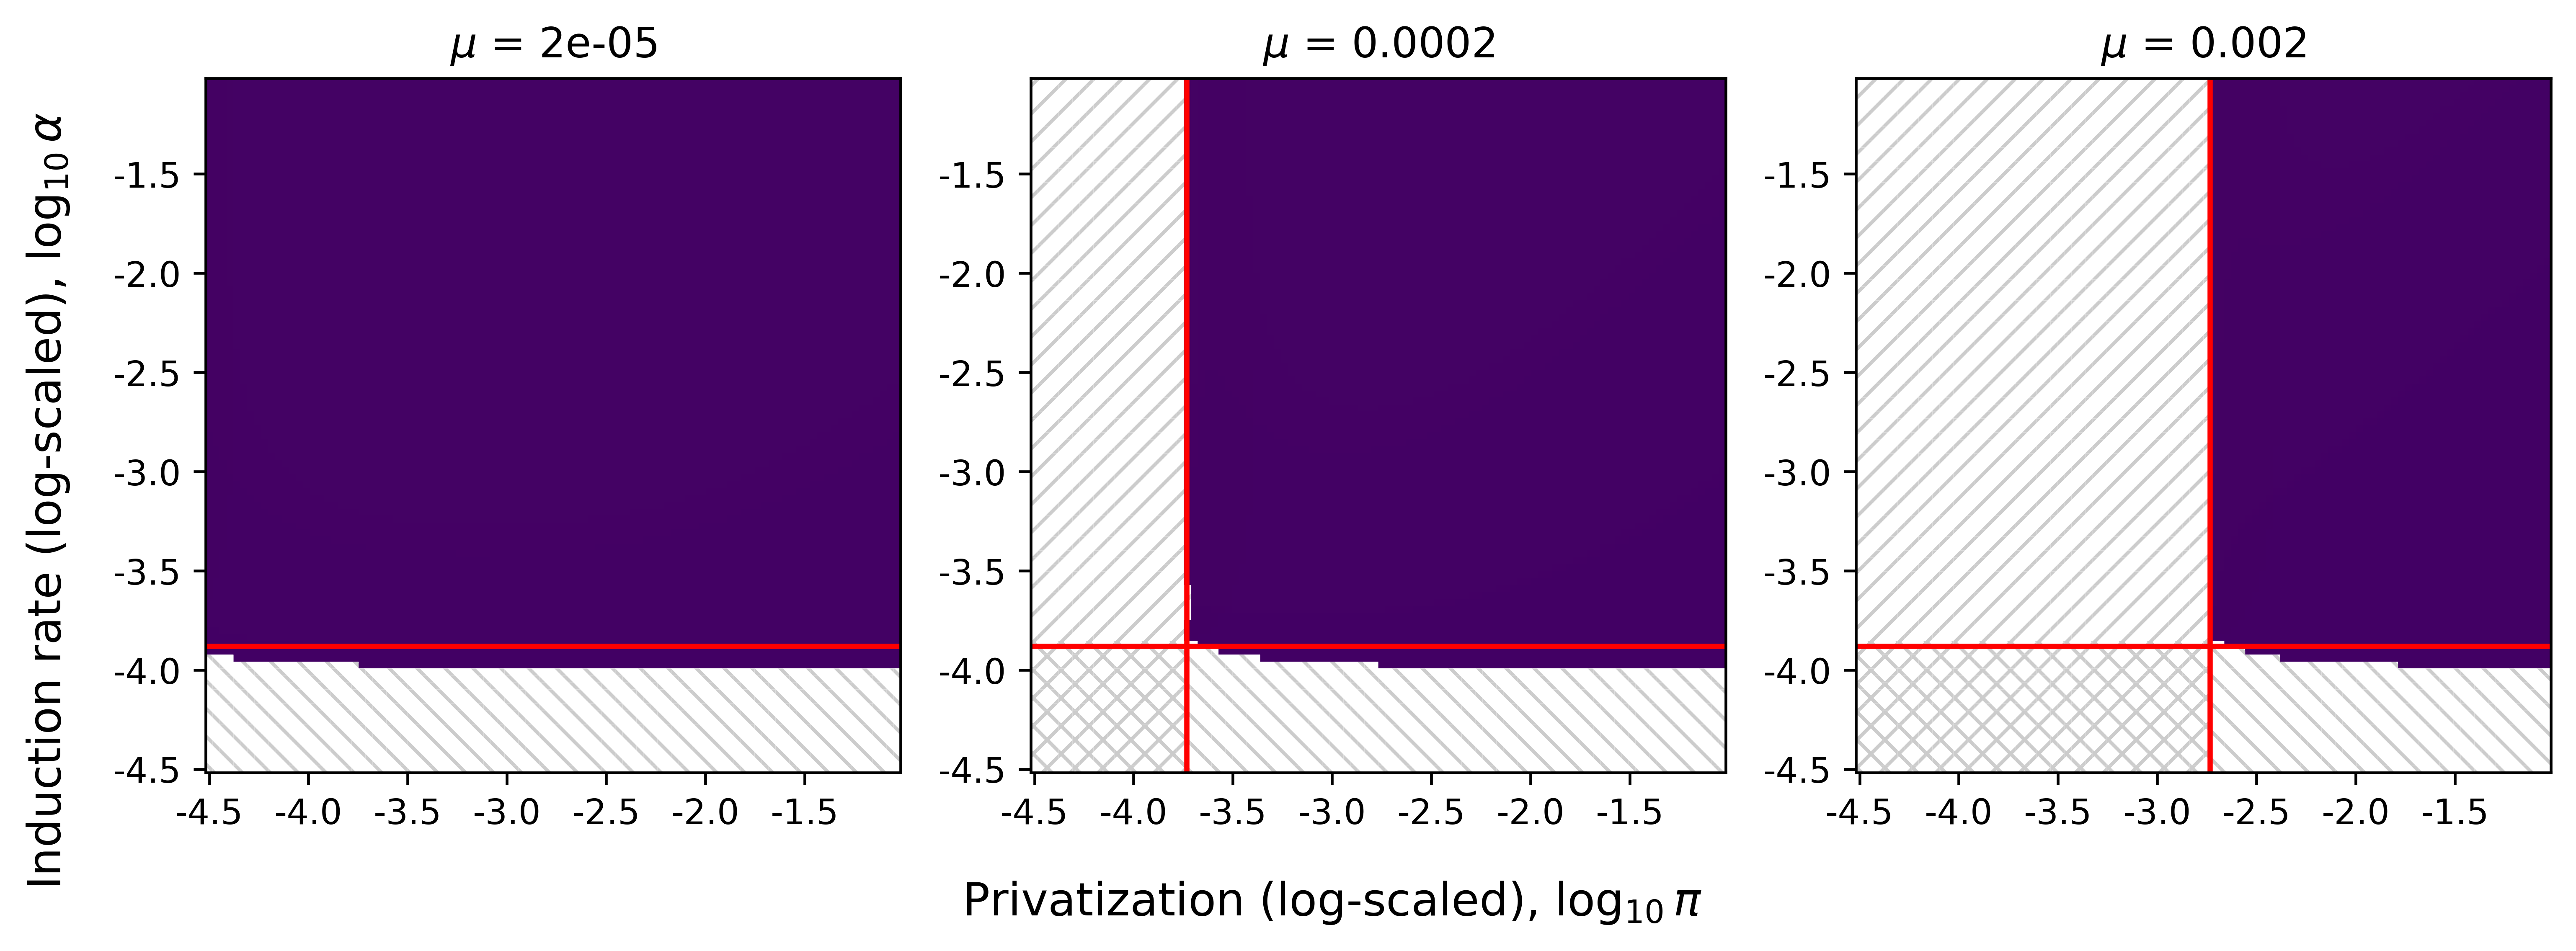

In [70]:
mus = np.array([0.00002, 0.0002, 0.002])
logpis = np.log10(mus/phi)
logalpha = np.log10(loss*(beta+delta)/(beta*(rV-1)-delta))

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 6), dpi=600)

for jj in range(3):
    dat = get_RGBA(np.array(result_1comp_mu[jj]))
    axes[jj].imshow(dat, origin="lower")
    axes[jj].set_xticks(np.linspace(0,100,8), np.linspace(-4.5,-1,8))
    axes[jj].set_yticks(np.linspace(0,100,8), np.linspace(-4.5,-1,8))
    
    axes[jj].set_title(r"$\mu$ = "+str(mus[jj]))
        
    gene = np.array(result_1comp_mu[jj])[:,:,-1].T
    gene = np.nan_to_num(gene, nan=-1)
    gene[gene>=0] = np.nan
    gene_mask = np.ma.masked_less(gene, 1)

    phage = np.array(result_1comp_mu[jj])[:,:,-2].T
    phage = np.nan_to_num(phage, nan=-1)
    phage[phage>=0] = np.nan
    phage_mask = np.ma.masked_less(phage, 1)
        
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data, hatch='///', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Gene extinct")
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), phage_mask.data, hatch='\\\\\\', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Phage extinct")
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data+phage_mask.data, hatch='xxx', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="")
    
    if (logpis[jj]>=-4.5):
        axes[jj].axvline(99+(logpis[jj]+1)*100/3.5, c='red')
    axes[jj].axhline(99+(logalpha+1)*100/3.5, c='red')
    
fig.text(0.5, 0.175, r"Privatization (log-scaled), $\log_{10}\pi$", ha='center',  fontsize=13)
fig.text(-0.02, 0.45, r"Induction rate (log-scaled), $\log_{10}\alpha$", va='center', rotation='vertical',  fontsize=13)

plt.tight_layout()
plt.savefig("mu_sens.png")

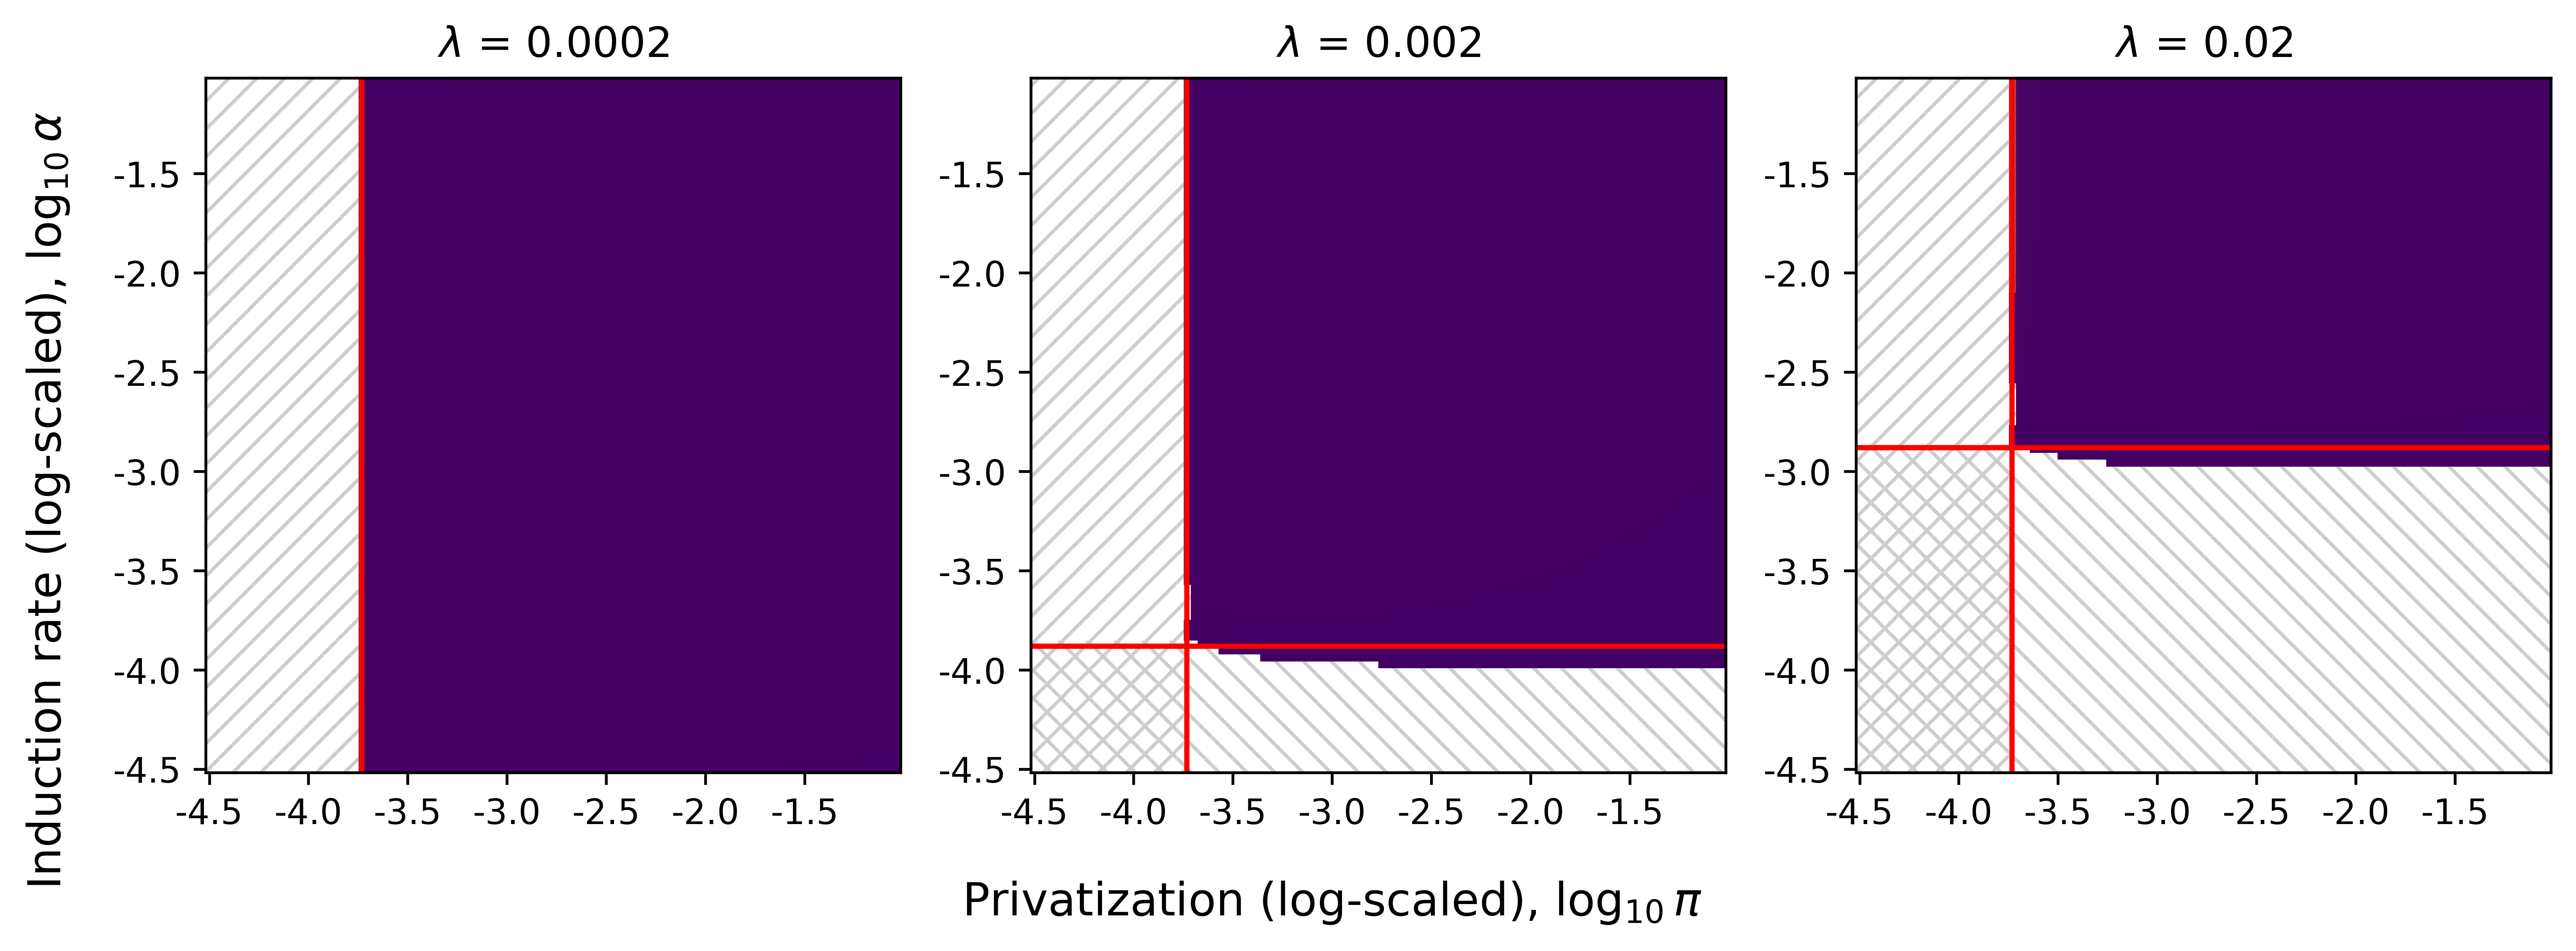

In [71]:
losses = np.array([0.0002, 0.002, 0.02])
logpi = np.log10(mu/phi)
logalphas = np.log10(losses*(beta+delta)/(beta*(rV-1)-delta))

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 6), dpi=600)

for jj in range(3):
    dat = get_RGBA(np.array(result_1comp_loss[jj]))
    axes[jj].imshow(dat, origin="lower")
    axes[jj].set_xticks(np.linspace(0,100,8), np.linspace(-4.5,-1,8))
    axes[jj].set_yticks(np.linspace(0,100,8), np.linspace(-4.5,-1,8))
    
    axes[jj].set_title(r"$\lambda$ = "+str(losses[jj]))
        
    gene = np.array(result_1comp_loss[jj])[:,:,-1].T
    gene = np.nan_to_num(gene, nan=-1)
    gene[gene>=0] = np.nan
    gene_mask = np.ma.masked_less(gene, 1)

    phage = np.array(result_1comp_loss[jj])[:,:,-2].T
    phage = np.nan_to_num(phage, nan=-1)
    phage[phage>=0] = np.nan
    phage_mask = np.ma.masked_less(phage, 1)
        
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data, hatch='///', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Gene extinct")
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), phage_mask.data, hatch='\\\\\\', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Phage extinct")
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data+phage_mask.data, hatch='xxx', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="")
    
    if (logalphas[jj]>=-4.5):
        axes[jj].axhline(99+(logalphas[jj]+1)*100/3.5, c='red')
    axes[jj].axvline(99+(logpi+1)*100/3.5, c='red')
    
fig.text(0.5, 0.175, r"Privatization (log-scaled), $\log_{10}\pi$", ha='center',  fontsize=13)
fig.text(-0.02, 0.45, r"Induction rate (log-scaled), $\log_{10}\alpha$", va='center', rotation='vertical',  fontsize=13)

plt.tight_layout()
plt.savefig("loss_sens.png")

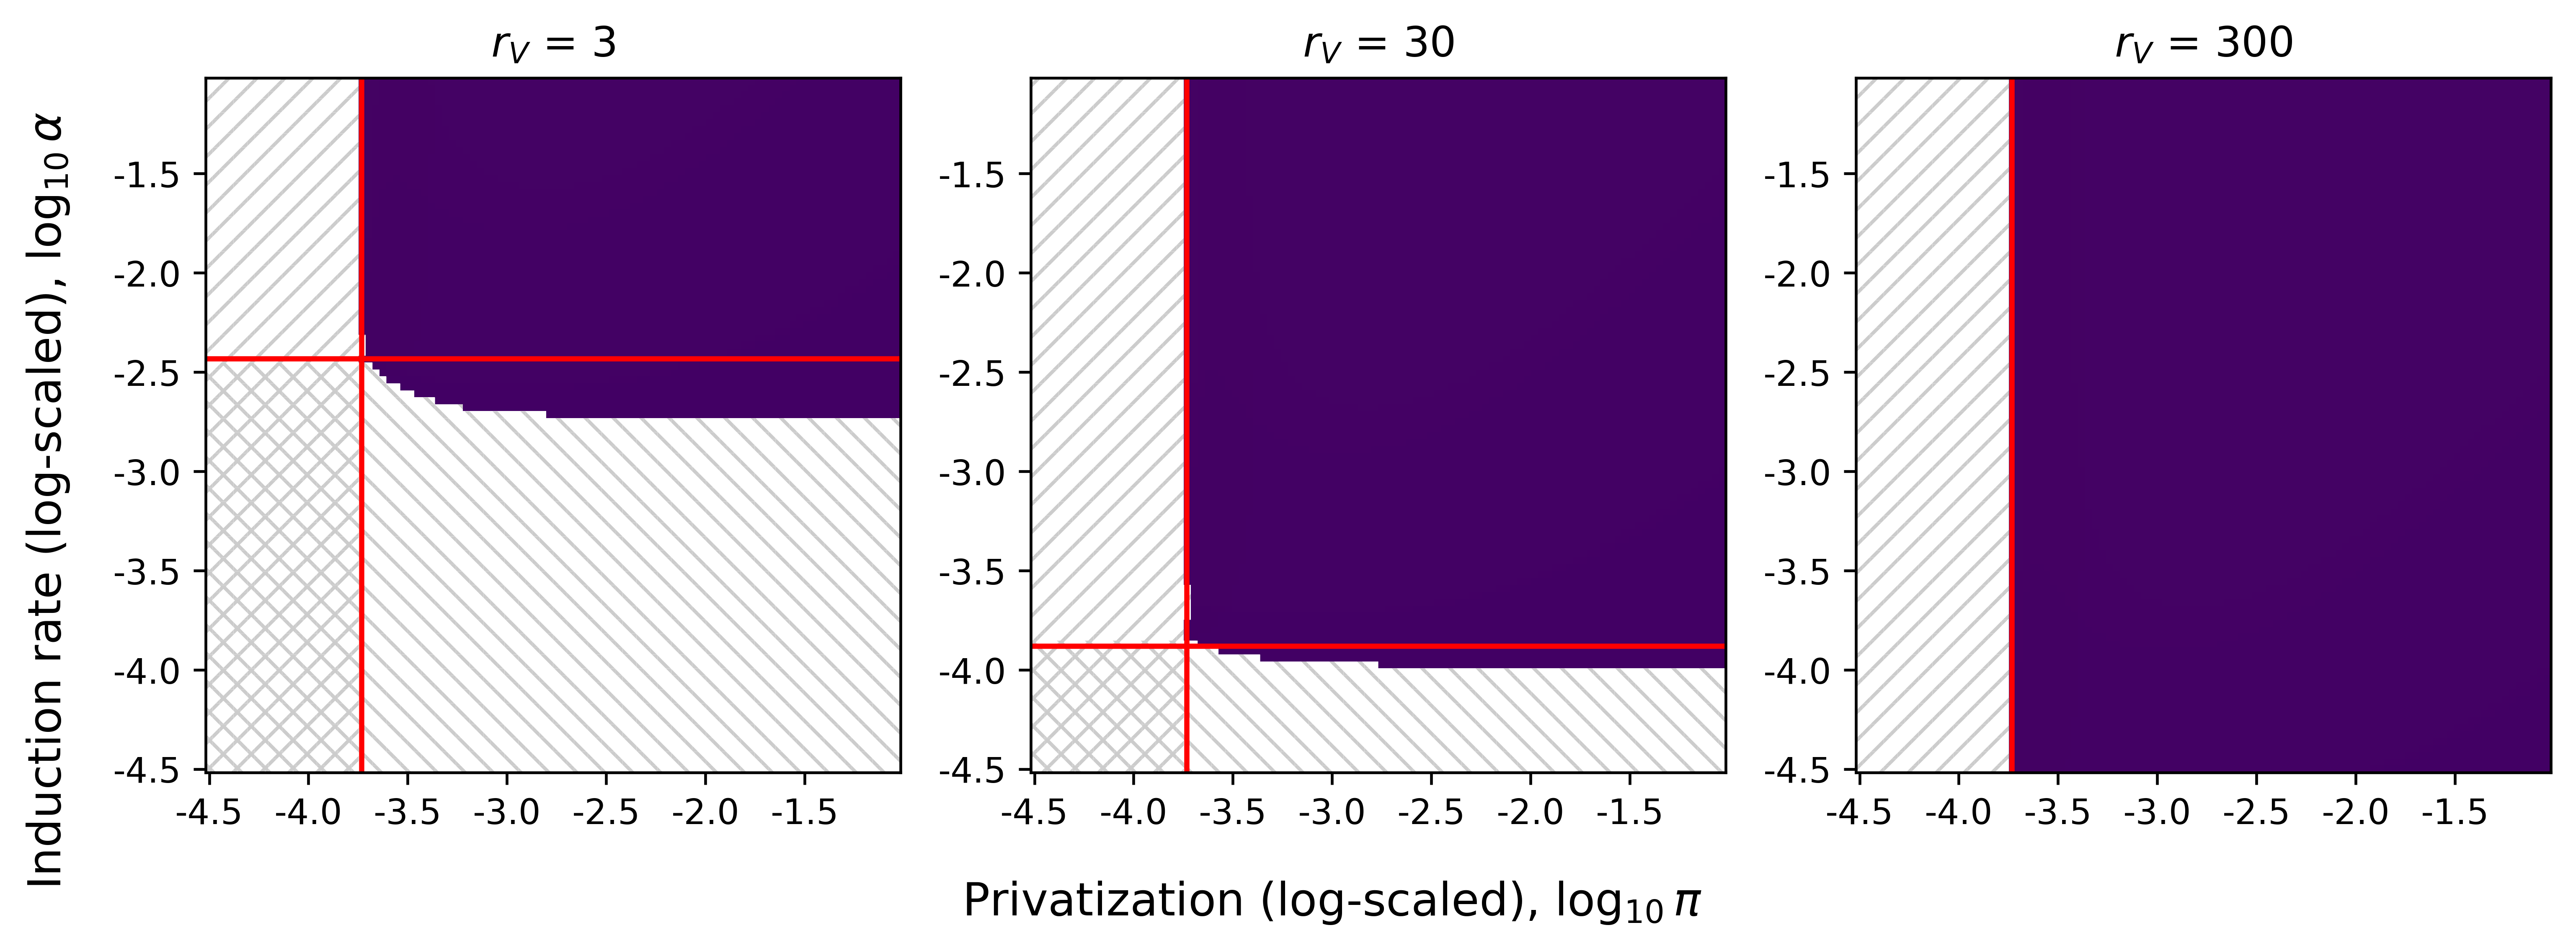

In [66]:
rVs = np.array([3, 30, 300])
logpi = np.log10(mu/phi)
logalphas = np.log10(loss*(beta+delta)/(beta*(rVs-1)-delta))

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 6), dpi=600)

for jj in range(3):
    dat = get_RGBA(np.array(result_1comp_rV[jj]))
    axes[jj].imshow(dat, origin="lower")
    axes[jj].set_xticks(np.linspace(0,100,8), np.linspace(-4.5,-1,8))
    axes[jj].set_yticks(np.linspace(0,100,8), np.linspace(-4.5,-1,8))
    
    axes[jj].set_title(r"$r_{V}$ = "+str(rVs[jj]))
        
    gene = np.array(result_1comp_rV[jj])[:,:,-1].T
    gene = np.nan_to_num(gene, nan=-1)
    gene[gene>=0] = np.nan
    gene_mask = np.ma.masked_less(gene, 1)

    phage = np.array(result_1comp_rV[jj])[:,:,-2].T
    phage = np.nan_to_num(phage, nan=-1)
    phage[phage>=0] = np.nan
    phage_mask = np.ma.masked_less(phage, 1)
        
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data, hatch='///', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Gene extinct")
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), phage_mask.data, hatch='\\\\\\', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Phage extinct")
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data+phage_mask.data, hatch='xxx', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="")
    
    if (logalphas[jj]>=-4.5):
        axes[jj].axhline(99+(logalphas[jj]+1)*100/3.5, c='red')
    axes[jj].axvline(99+(logpi+1)*100/3.5, c='red')
    
fig.text(0.5, 0.175, r"Privatization (log-scaled), $\log_{10}\pi$", ha='center',  fontsize=13)
fig.text(-0.02, 0.45, r"Induction rate (log-scaled), $\log_{10}\alpha$", va='center', rotation='vertical',  fontsize=13)

plt.tight_layout()
plt.savefig("rV_sens.png")

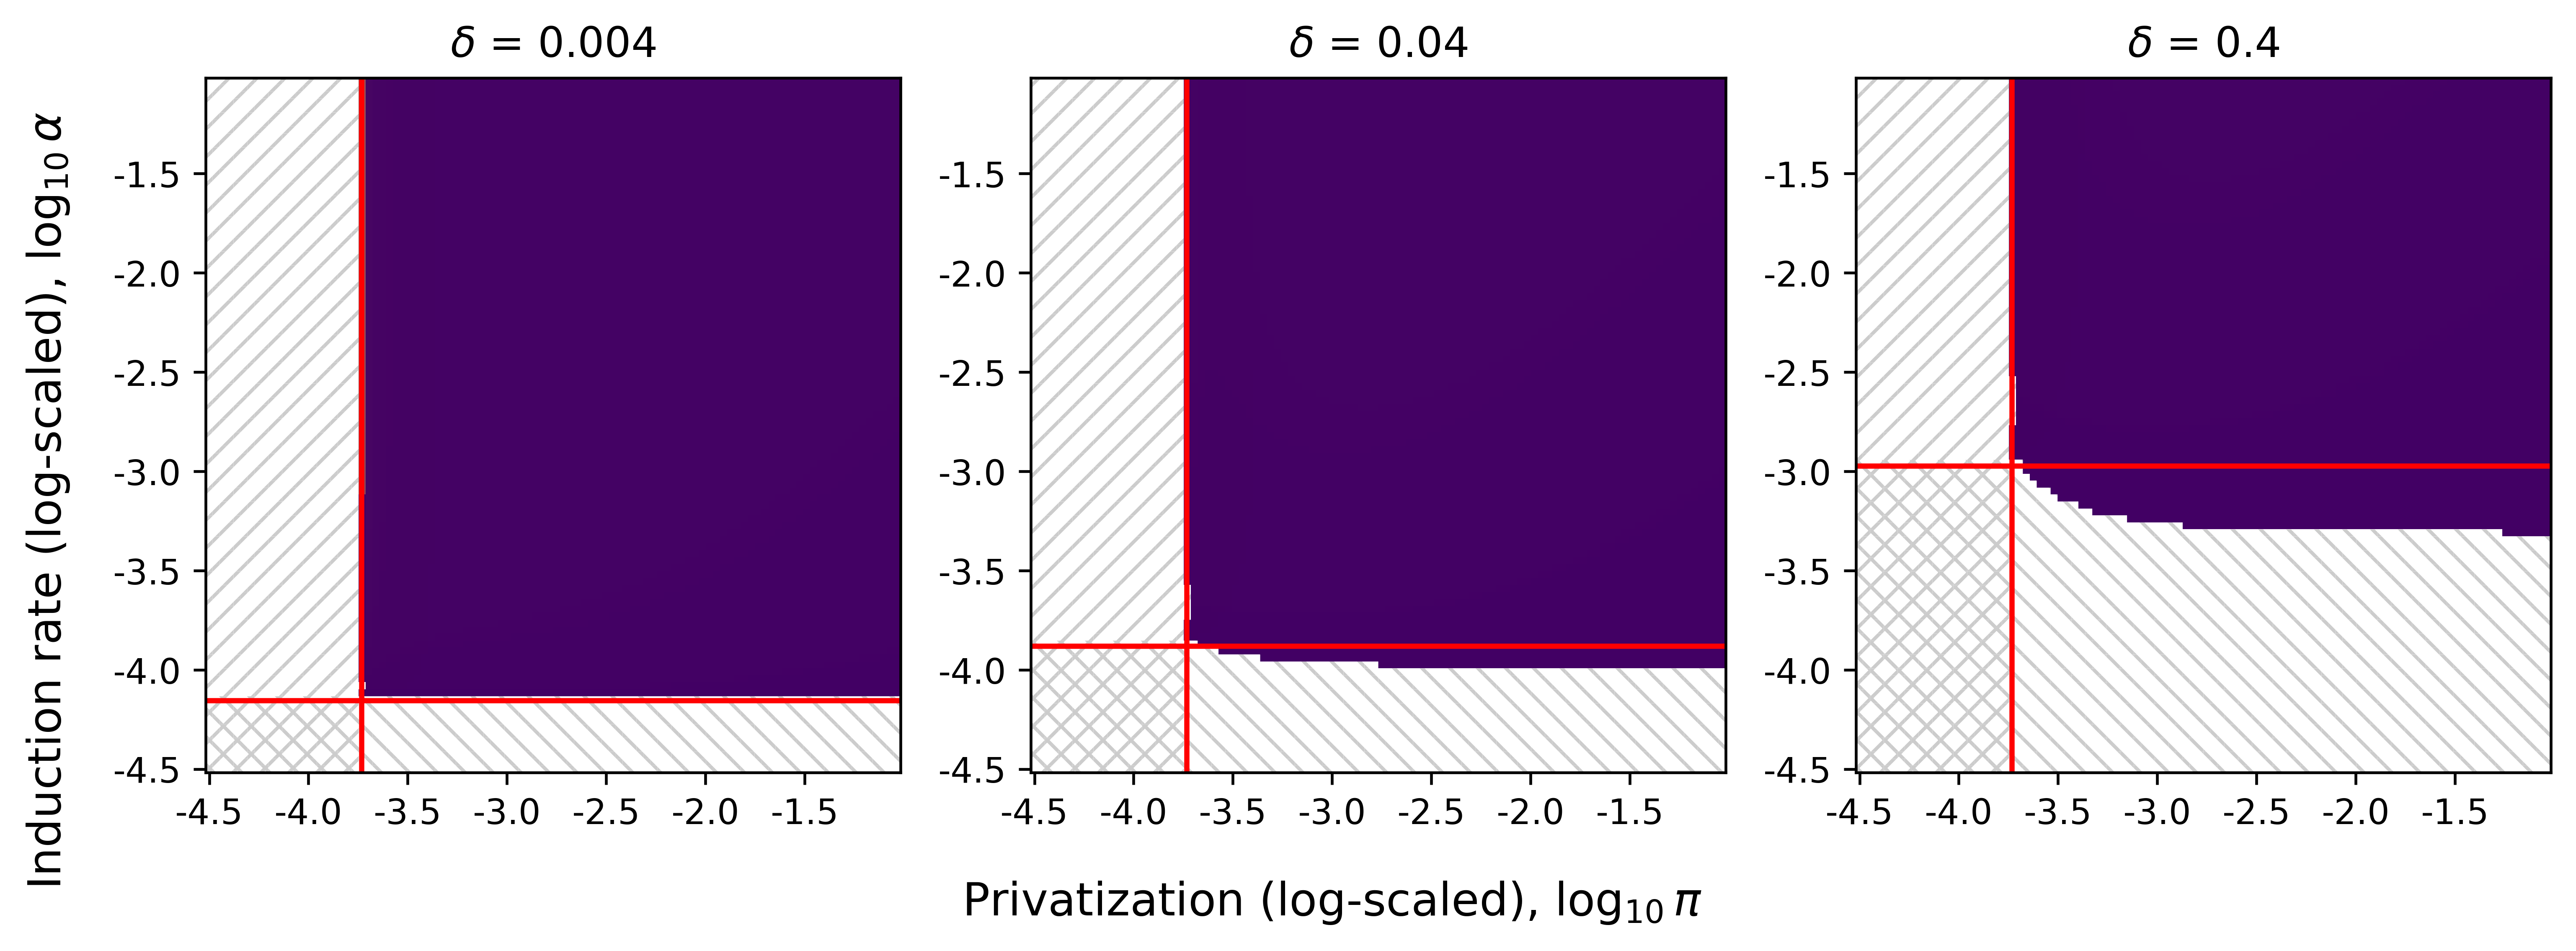

In [60]:
deltas = np.array([0.004, 0.04, 0.4])
logpi = np.log10(mu/phi)
logalphas = np.log10(loss*(beta+deltas)/(beta*(rV-1)-deltas))

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 6), dpi=600)

for jj in range(3):
    dat = get_RGBA(np.array(result_1comp_delta[jj]))
    axes[jj].imshow(dat, origin="lower")
    axes[jj].set_xticks(np.linspace(0,100,8), np.linspace(-4.5,-1,8))
    axes[jj].set_yticks(np.linspace(0,100,8), np.linspace(-4.5,-1,8))
    
    axes[jj].set_title(r"$\delta$ = "+str(deltas[jj]))
        
    gene = np.array(result_1comp_delta[jj])[:,:,-1].T
    gene = np.nan_to_num(gene, nan=-1)
    gene[gene>=0] = np.nan
    gene_mask = np.ma.masked_less(gene, 1)

    phage = np.array(result_1comp_delta[jj])[:,:,-2].T
    phage = np.nan_to_num(phage, nan=-1)
    phage[phage>=0] = np.nan
    phage_mask = np.ma.masked_less(phage, 1)
        
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data, hatch='///', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Gene extinct")
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), phage_mask.data, hatch='\\\\\\', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Phage extinct")
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data+phage_mask.data, hatch='xxx', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="")
    
    if (logalphas[jj]>=-4.5):
        axes[jj].axhline(99+(logalphas[jj]+1)*100/3.5, c='red')
    axes[jj].axvline(99+(logpi+1)*100/3.5, c='red')
    
fig.text(0.5, 0.175, r"Privatization (log-scaled), $\log_{10}\pi$", ha='center',  fontsize=13)
fig.text(-0.02, 0.45, r"Induction rate (log-scaled), $\log_{10}\alpha$", va='center', rotation='vertical',  fontsize=13)

plt.tight_layout()
plt.savefig("delta_sens.png")

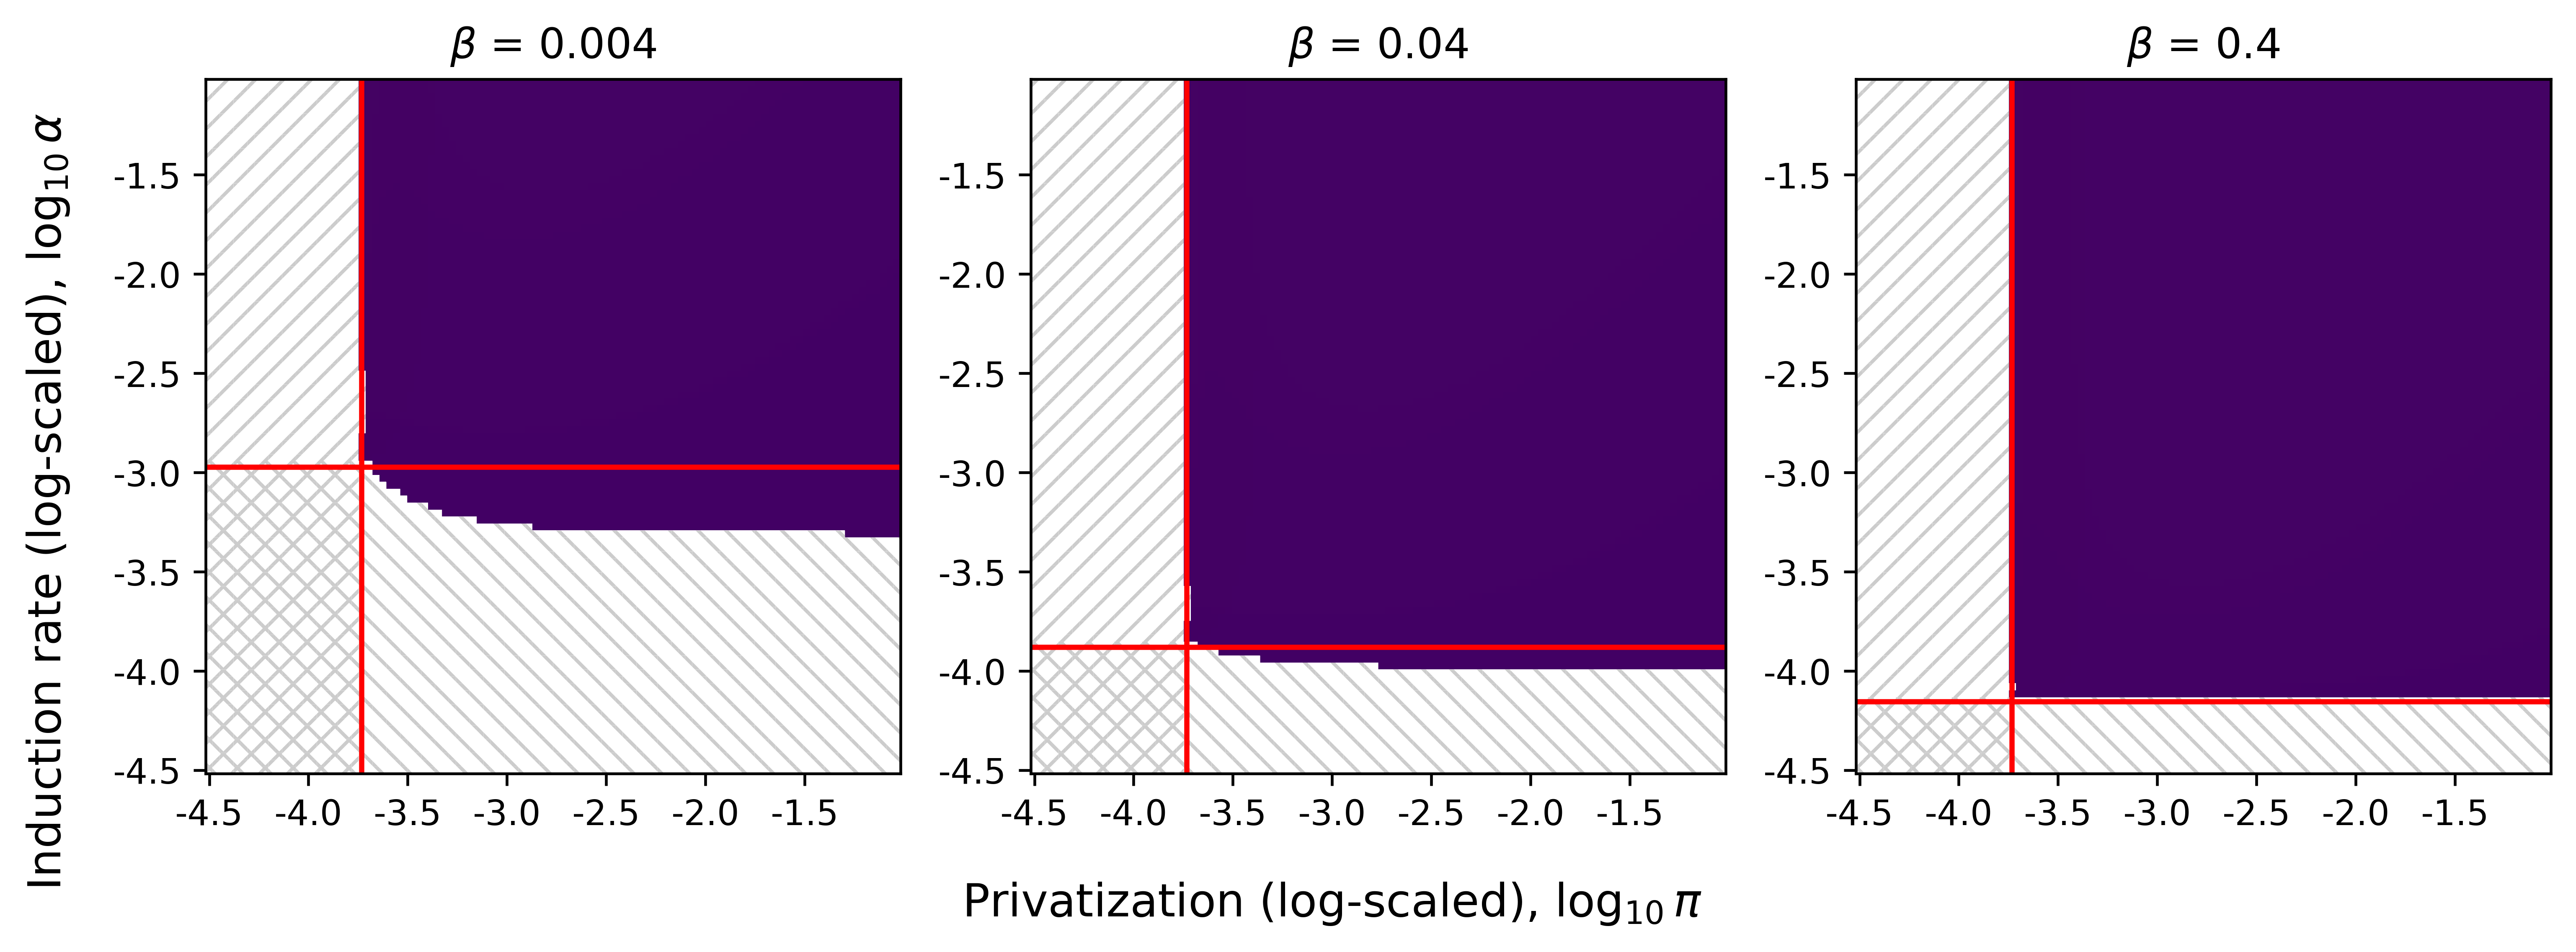

In [67]:
betas = np.array([0.004, 0.04, 0.4])
logpi = np.log10(mu/phi)
logalphas = np.log10(loss*(betas+delta)/(betas*(rV-1)-delta))

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 6), dpi=600)

for jj in range(3):
    dat = get_RGBA(np.array(result_1comp_beta[jj]))
    axes[jj].imshow(dat, origin="lower")
    axes[jj].set_xticks(np.linspace(0,100,8), np.linspace(-4.5,-1,8))
    axes[jj].set_yticks(np.linspace(0,100,8), np.linspace(-4.5,-1,8))
    
    axes[jj].set_title(r"$\beta$ = "+str(betas[jj]))
        
    gene = np.array(result_1comp_beta[jj])[:,:,-1].T
    gene = np.nan_to_num(gene, nan=-1)
    gene[gene>=0] = np.nan
    gene_mask = np.ma.masked_less(gene, 1)

    phage = np.array(result_1comp_beta[jj])[:,:,-2].T
    phage = np.nan_to_num(phage, nan=-1)
    phage[phage>=0] = np.nan
    phage_mask = np.ma.masked_less(phage, 1)
        
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data, hatch='///', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Gene extinct")
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), phage_mask.data, hatch='\\\\\\', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Phage extinct")
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data+phage_mask.data, hatch='xxx', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="")
    
    if (logalphas[jj]>=-4.5):
        axes[jj].axhline(99+(logalphas[jj]+1)*100/3.5, c='red')
    axes[jj].axvline(99+(logpi+1)*100/3.5, c='red')
    
fig.text(0.5, 0.175, r"Privatization (log-scaled), $\log_{10}\pi$", ha='center',  fontsize=13)
fig.text(-0.02, 0.45, r"Induction rate (log-scaled), $\log_{10}\alpha$", va='center', rotation='vertical',  fontsize=13)

plt.tight_layout()
plt.savefig("beta_sens.png")

In [79]:
# Define model

def model1comp_flux(y, t, pi, alpha, mu, loss, phi, beta, rV, delta, d, K, flux, gfreq, pfreq):
    
    # Define state variables.
    U, Uc, L, Lc, Lp, Lcp, V, VT = y

    N = U + Uc + L + Lc + Lp + Lcp
    NT = Uc + Lc + Lp + Lcp
    
    ####... growth/death....... selection................... infection............ lysis.... mutations/decay................. migration.....

    dydt = [U*(1 - d - N      + (1-pi)*phi*NT/N)           - beta*U*(V + VT)               + loss*(L + Lp) + mu*Uc          -flux*U + K*flux*(1-gfreq)*(1-pfreq),
            Uc*(1 - d - N     + pi*phi + (1-pi)*phi*NT/N)  - beta*Uc*(V + VT)              + loss*(Lc + Lcp) - mu*Uc        -flux*Uc + K*flux*gfreq*(1-pfreq),
            L*(1 - d - N      + (1-pi)*phi*NT/N)           + beta*U*V            - (alpha  + loss)*L + mu*Lc + mu*Lp        -flux*L + K*flux*(1-gfreq)*pfreq,
            Lc*(1 - d - N     + pi*phi + (1-pi)*phi*NT/N)  + beta*Uc*V           - (alpha  + loss)*Lc - mu*Lc + mu*Lcp      -flux*Lc + K*flux*gfreq*pfreq,
            Lp*(1 - d - N     + pi*phi + (1-pi)*phi*NT/N)  + beta*U*VT           - (alpha  + loss)*Lp - mu*Lp + mu*Lcp      -flux*Lp,
            Lcp*(1 - d - N    + pi*phi + (1-pi)*phi*NT/N)  + beta*Uc*VT          - (alpha  + loss)*Lcp - mu*Lcp - mu*Lcp    -flux*Lcp,
            rV*alpha*(L + Lc)                              - beta*(U+Uc)*V                 - delta*V                        -flux*V,
            rV*alpha*(Lp + Lcp)                            - beta*(U+Uc)*VT                - delta*VT                       -flux*VT]                   

    return dydt

In [83]:
# Run simulation for single host compartment with influx/efflux terms

result_1comp_inex = []

# Assign parameter values

beta = 0.04         # phage infection rate
loss = 0.002        # Rate of prophage loss
mu = 0.0002          # Rate of gene loss
rV = 30             # phage burst size
delta = 0.04        # Rate of virion decay
d = 0.02            # Cell intrinsic death rate
phi = 1             # Maximum increase in carrying capacity due to benefits from gene
alpha = 10**(-2)
pi = 10**(-2.5)
K = 1

for flux in [0.0001, 0.001, 0.01]:
    sweep = []
    # For different values of pi (privatization of benefits within the host compertment) on the log-scale
    for gfreq in np.linspace(0,1,100):
        pvals = []
        # For different values of alpha (rate of prophage induction within the host compartment) on the log-scale
        for pfreq in np.linspace(0,1,100):
        
            # Initial condition: Host contains 99% Lc and 1% Lp at carrying capacity, Outside world contains U at carrying capacity
            y0 = [0.00, 0.00, 0.00, 1.98, 0.02, 0.00, 0.00, 0.00]
            ##    U     Uc    L     Lc    Lp    Lcp   V     VT   

            t = np.linspace(0, 1000000, 100001)
            sol = odeint(model1comp_flux, y0, t, args=(pi, alpha, mu, loss, phi, beta, rV, delta, d, K, flux, gfreq, pfreq))
        
            data = pd.DataFrame(sol, columns = ["U", "Uc", "L", "Lc", "Lp", "Lcp", "V", "VT"])
            data[data<10**-6]=0
            data['phageG'] = (data['Lp']+data['Lcp'])/(data['L']+data['Lc']+data['Lp']+data['Lcp'])
            data['geneP'] = (data['Lp']+data['Lcp'])/(data['Uc']+data['Lc']+data['Lp']+2*data['Lcp'])
        
            pvals.append(data.iloc[-1])
        sweep.append(pvals)
    result_1comp_inex.append(sweep)

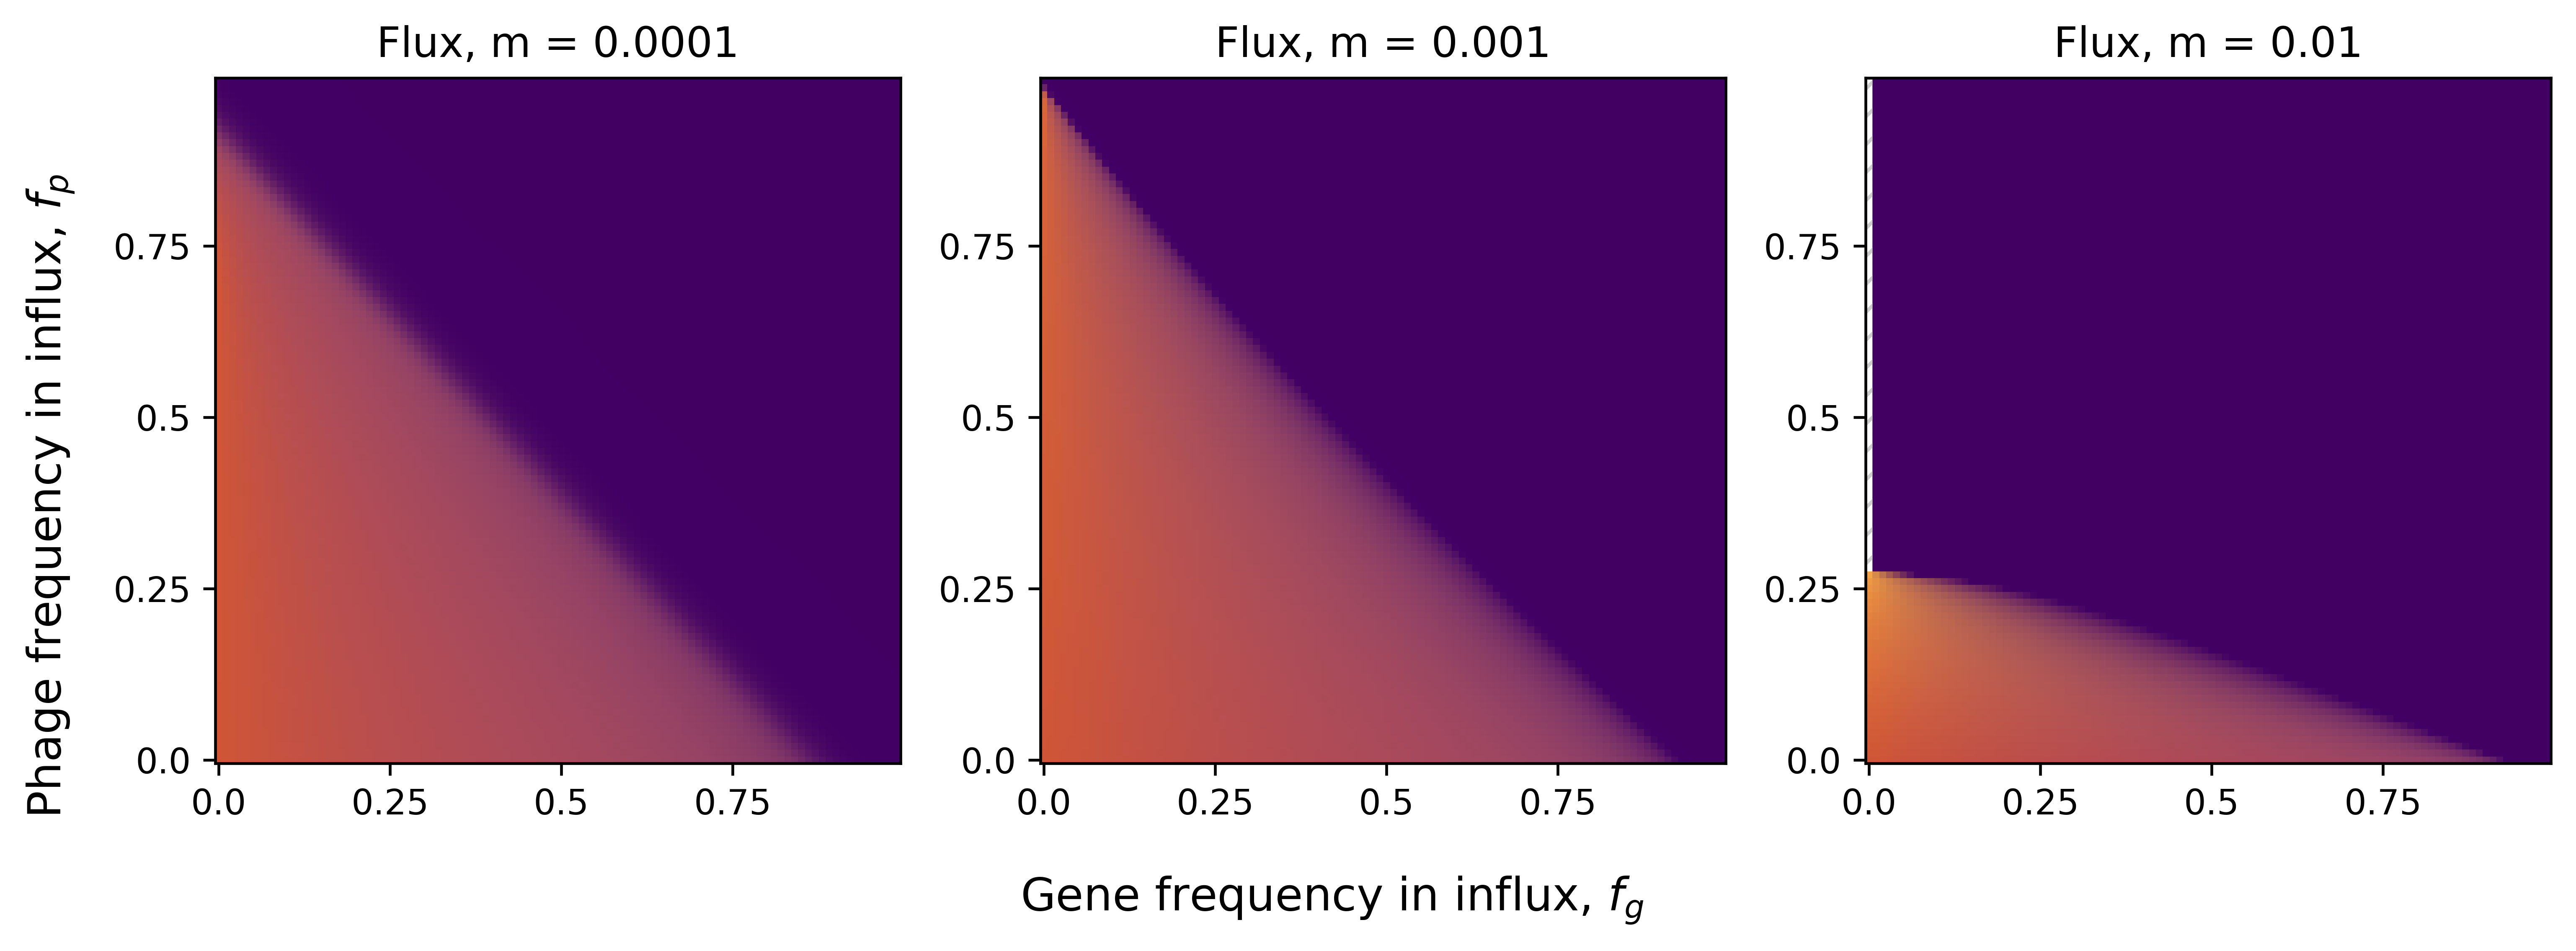

In [84]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 6), dpi=600)
fluxes = [0.0001, 0.001, 0.01]
for jj in range(3):
    dat = get_RGBA(np.array(result_1comp_inex[jj]))
    axes[jj].imshow(dat, origin="lower")
    axes[jj].set_xticks(np.linspace(0,100,5), np.linspace(0,1,5))
    axes[jj].set_yticks(np.linspace(0,100,5), np.linspace(0,1,5))
        
    gene = np.array(result_1comp_inex[jj])[:,:,-1].T
    gene = np.nan_to_num(gene, nan=-1)
    gene[gene>=0] = np.nan
    gene_mask = np.ma.masked_less(gene, 1)

    phage = np.array(result_1comp_inex[jj])[:,:,-2].T
    phage = np.nan_to_num(phage, nan=-1)
    phage[phage>=0] = np.nan
    phage_mask = np.ma.masked_less(phage, 1)
    
    axes[jj].set_title(f"Flux, m = {fluxes[jj]}")
        
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data, hatch='///', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Gene extinct")
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), phage_mask.data, hatch='\\\\\\', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="Phage extinct")
    axes[jj].pcolor(np.linspace(0,99,100), np.linspace(0,99,100), gene_mask.data+phage_mask.data, hatch='xxx', alpha=1, linewidth=0, cmap=ListedColormap(['white']), edgecolor='#CCCCCC', label="")
    
fig.text(0.5, 0.175, r"Gene frequency in influx, $f_{g}$", ha='center',  fontsize=13)
fig.text(-0.02, 0.45, r"Phage frequency in influx, $f_{p}$", va='center', rotation='vertical',  fontsize=13)

plt.tight_layout()
plt.savefig("flux_model.png", bbox_inches = 'tight')